# Applied Exercise 7 - Random Forests on the Boston Data

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree

import warnings
warnings.filterwarnings("ignore")

In [6]:
data = load_data("Boston")
X = data.drop(columns="medv")
y = data["medv"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
max_features_values = range(1, X.shape[1] + 1)
n_estimators_values = [50, 100, 200, 300, 500]

results = []
for n in n_estimators_values:
    for m in max_features_values:
        rf = RandomForestRegressor(n_estimators=n, max_features=m, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        predictions = rf.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        results.append([m, n, mse])

results = pd.DataFrame(results, columns=["max_features", "n_estimators", "Test_MSE"])

print("=" * 60)
print("RANDOM FOREST TEST ERRORS")
print("=" * 60)
print(results)

RANDOM FOREST TEST ERRORS
    max_features  n_estimators   Test_MSE
0              1            50  14.719937
1              2            50  11.629620
2              3            50  10.124335
3              4            50   9.728560
4              5            50   9.823222
5              6            50   9.350777
6              7            50   9.066230
7              8            50  10.321340
8              9            50   9.381376
9             10            50   8.949442
10            11            50   9.769647
11            12            50   9.349104
12             1           100  13.695061
13             2           100  11.430249
14             3           100   9.524454
15             4           100   9.408396
16             5           100   9.580961
17             6           100   8.939488
18             7           100   8.790998
19             8           100   9.358174
20             9           100   8.781779
21            10           100   8.502366
22      

BEST RANDOM FOREST
max_features = 12
n_estimators = 300
Test MSE = 8.3582


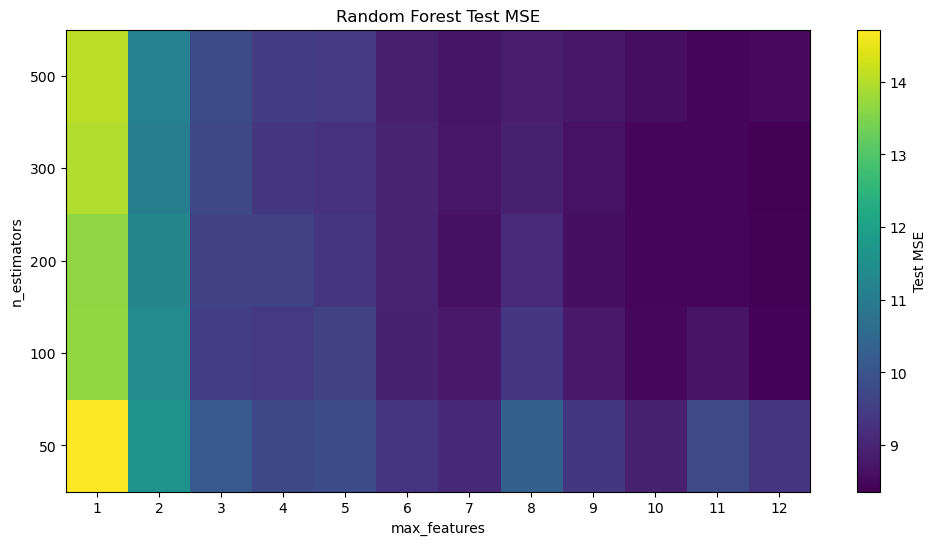

In [7]:
best = results.loc[results["Test_MSE"].idxmin()]

print("=" * 60)
print("BEST RANDOM FOREST")
print("=" * 60)
print(f"max_features = {int(best['max_features'])}")
print(f"n_estimators = {int(best['n_estimators'])}")
print(f"Test MSE = {best['Test_MSE']:.4f}")

plot_data = results.pivot(index="n_estimators", columns="max_features", values="Test_MSE")

plt.figure(figsize=(12, 6))
plt.imshow(plot_data, aspect="auto", origin="lower")
plt.colorbar(label="Test MSE")
plt.xticks(range(len(plot_data.columns)), plot_data.columns)
plt.yticks(range(len(plot_data.index)), plot_data.index)
plt.xlabel("max_features")
plt.ylabel("n_estimators")
plt.title("Random Forest Test MSE")
plt.show()

- With max_features = 1, the test MSE is quite high, around 13–14. As max_features increased, the test MSE generally decreased.
- The best performance occurs when max_features is close to the total number of predictors.
- Increasing n_estimators from 50 to 500 generally improves or stabilizes the results, although the improvement becomes relatively small after around 200–300 trees. The improvement from 300 to 500 trees is actually slightly worse at the best max_features, with 300 trees - 8.3582 and 500 trees - 8.5319.
- This illustrates that more trees do not necessarily give a lower test error for a particular random train/test split. Once there are enough trees, the random forest has largely stabilized.
- Depending on the business problem statement can number of trees be selected. If the requiement is a better model but can accept a complex model with more iterations, n = 300 can be selected. If the number of records is very high and trade-off of little variance for an efficient model can be accepted, n = 100 can be selected.

# Applied Exercise 8 - Regression Trees on Carseats

In [4]:
data = load_data("Carseats")
data = pd.get_dummies(data, columns=["ShelveLoc", "Urban", "US"], drop_first=True)
data = data.astype(float)

X = data.drop(columns="Sales")
y = data["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

TRAIN / TEST SPLIT
Training observations: 280
Test observations: 120


REGRESSION TREE
Test MSE = 6.2144
Number of leaves = 279


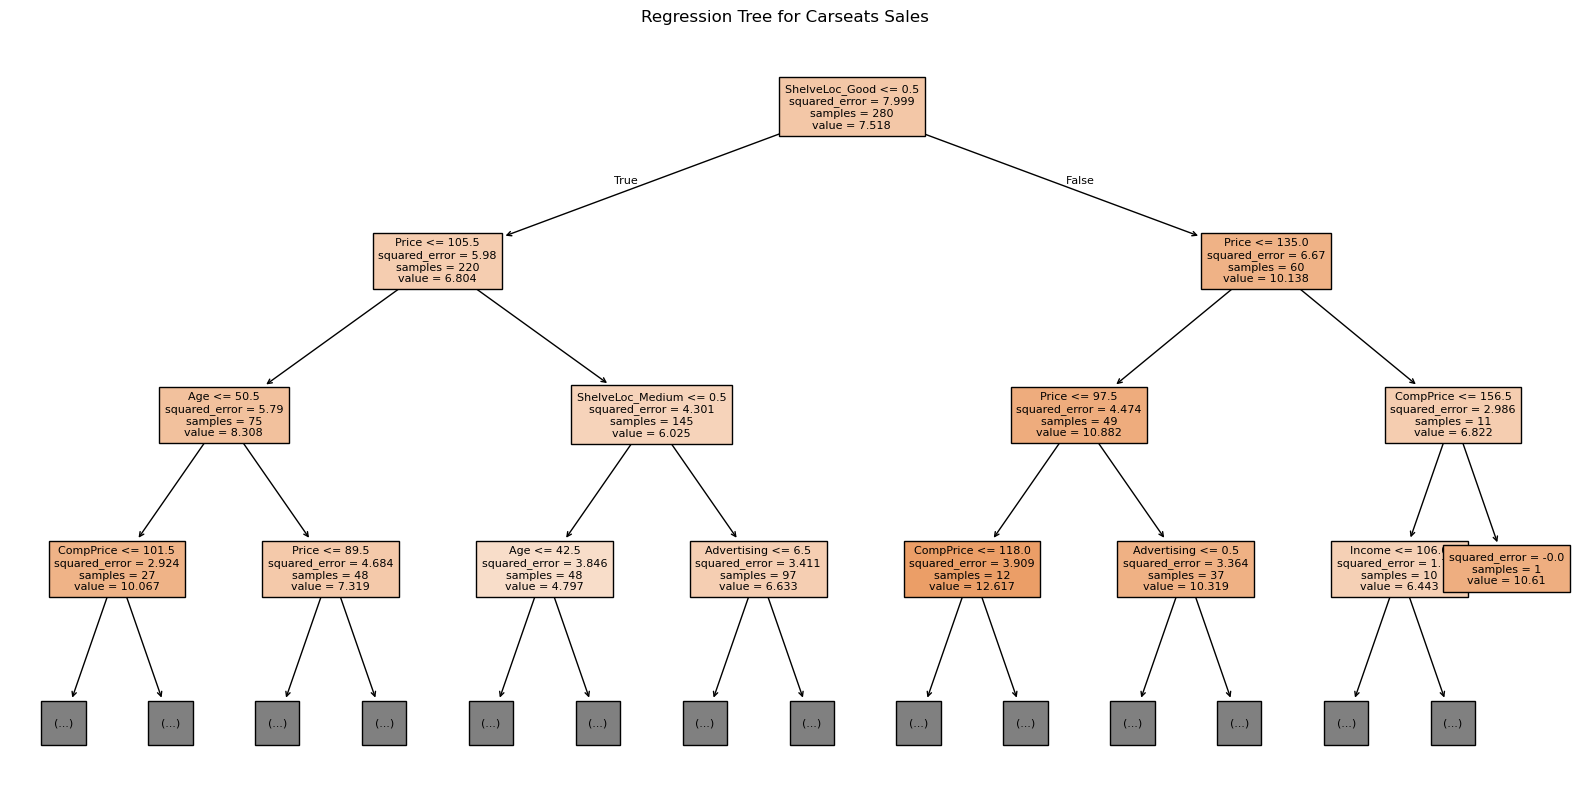

In [8]:
tree = DecisionTreeRegressor(random_state=1)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_mse = mean_squared_error(y_test, tree_pred)

print("=" * 60)
print("REGRESSION TREE")
print("=" * 60)
print(f"Test MSE = {tree_mse:.4f}")
print(f"Number of leaves = {tree.get_n_leaves()}")

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, max_depth=3, fontsize=8)
plt.title("Regression Tree for Carseats Sales")
plt.show()

CROSS-VALIDATION FOR TREE COMPLEXITY
    Max_Depth    CV_MSE
0           2  5.463816
1           3  4.968145
2           4  4.960895
3           5  4.824629
4           6  4.978975
5           7  4.919038
6           8  4.607852
7           9  4.891719
8          10  4.927139
9          11  4.951761
10         12  4.739386
11         13  5.060645
12         14  4.905402
13         15  4.956675

Optimal maximum depth = 8
Pruned tree Test MSE = 5.7969


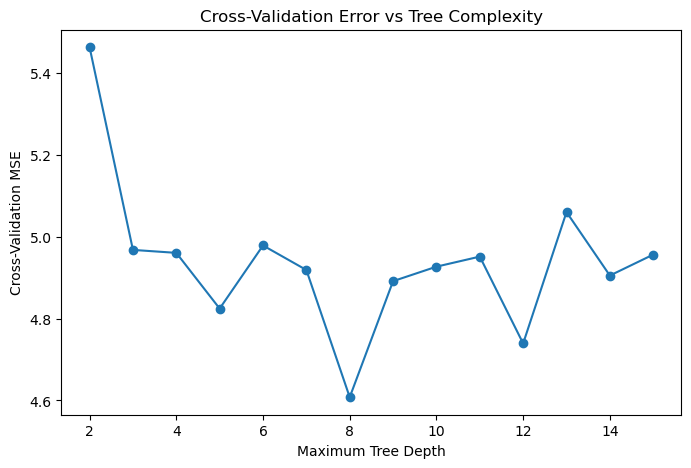

In [9]:
depths = range(2, 16)
cv_errors = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=1)
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
    cv_errors.append(-scores.mean())

cv_results = pd.DataFrame({"Max_Depth": depths, "CV_MSE": cv_errors})
best_depth = cv_results.loc[cv_results["CV_MSE"].idxmin(), "Max_Depth"]

pruned_tree = DecisionTreeRegressor(max_depth=int(best_depth), random_state=1)
pruned_tree.fit(X_train, y_train)
pruned_pred = pruned_tree.predict(X_test)
pruned_mse = mean_squared_error(y_test, pruned_pred)

print("=" * 60)
print("CROSS-VALIDATION FOR TREE COMPLEXITY")
print("=" * 60)
print(cv_results)
print(f"\nOptimal maximum depth = {best_depth}")
print(f"Pruned tree Test MSE = {pruned_mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(depths, cv_errors, marker="o")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Cross-Validation MSE")
plt.title("Cross-Validation Error vs Tree Complexity")
plt.show()

In [10]:
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=1), n_estimators=500, max_features=1.0, random_state=1, n_jobs=-1)
bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)
bag_mse = mean_squared_error(y_test, bag_pred)

print("=" * 60)
print("BAGGING")
print("=" * 60)
print(f"Test MSE = {bag_mse:.4f}")

bag_importance = np.mean([tree.feature_importances_ for tree in bagging.estimators_], axis=0)
bag_importance = pd.Series(bag_importance, index=X.columns).sort_values(ascending=False)

print("\nVariable Importance:")
print(bag_importance)

BAGGING
Test MSE = 2.8575

Variable Importance:
Price               0.294381
ShelveLoc_Good      0.232177
Age                 0.101780
CompPrice           0.096533
Advertising         0.076962
ShelveLoc_Medium    0.070323
Income              0.047261
Population          0.043462
Education           0.027763
Urban_Yes           0.005718
US_Yes              0.003641
dtype: float64


RANDOM FOREST
     m  Test_MSE
0    1  4.148951
1    2  3.434469
2    3  3.002618
3    4  2.922220
4    5  2.784704
5    6  2.844705
6    7  2.807297
7    8  2.759271
8    9  2.769298
9   10  2.831370
10  11  2.852290

Best m = 8
Best Random Forest Test MSE = 2.7593

Variable Importance:
Price               0.282703
ShelveLoc_Good      0.222861
Age                 0.102587
CompPrice           0.098094
Advertising         0.085485
ShelveLoc_Medium    0.064600
Income              0.052008
Population          0.049169
Education           0.030242
Urban_Yes           0.006199
US_Yes              0.006052
dtype: float64


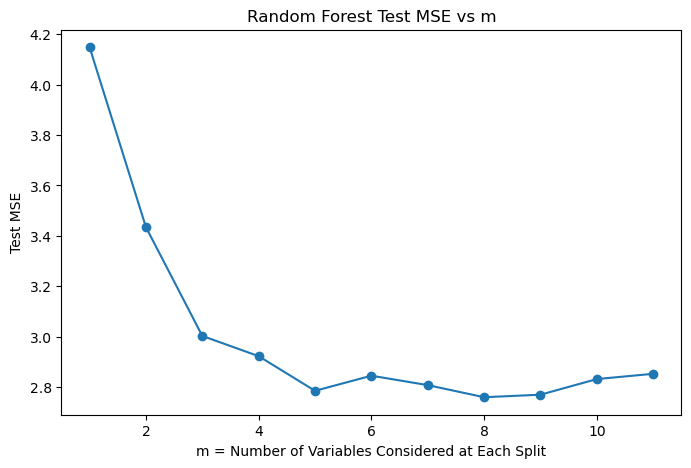

In [11]:
m_values = range(1, X.shape[1] + 1)
rf_results = []

for m in m_values:
    rf = RandomForestRegressor(n_estimators=500, max_features=m, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_mse = mean_squared_error(y_test, rf_pred)
    rf_results.append([m, rf_mse])

rf_results = pd.DataFrame(rf_results, columns=["m", "Test_MSE"])
best_rf = rf_results.loc[rf_results["Test_MSE"].idxmin()]
rf = RandomForestRegressor(n_estimators=500, max_features=int(best_rf["m"]), random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(rf_results)
print(f"\nBest m = {int(best_rf['m'])}")
print(f"Best Random Forest Test MSE = {rf_mse:.4f}")

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nVariable Importance:")
print(rf_importance)

plt.figure(figsize=(8, 5))
plt.plot(rf_results["m"], rf_results["Test_MSE"], marker="o")
plt.xlabel("m = Number of Variables Considered at Each Split")
plt.ylabel("Test MSE")
plt.title("Random Forest Test MSE vs m")
plt.show()


In [12]:
comparison = pd.DataFrame({"Method": ["Regression Tree", "Pruned Tree", "Bagging", "Random Forest"],
                           "Test_MSE": [tree_mse, pruned_mse, bag_mse, rf_mse]})

print("=" * 60)
print("COMPARISON OF TEST ERRORS")
print("=" * 60)
print(comparison)

COMPARISON OF TEST ERRORS
            Method  Test_MSE
0  Regression Tree  6.214416
1      Pruned Tree  5.796857
2          Bagging  2.857465
3    Random Forest  2.759271


- The single regression tree provides an interpretable model but can have relatively high variance. Bagging reduces this variance by averaging many trees, while random forests additionally randomize the predictors considered at each split. BART provides another ensemble approach based on a sum of Bayesian regression trees.
- The best approach is determined by the lowest test MSE, rather than the training error. From the results, Bagging and Random Forest performed almost similarly while regression tree had the highest while pruned tree reduced the test MSE slightly.